# Step 6 & 7 결과 확인\n\n- **Step 6**: Risk Score → w_risky 매핑 + CAL 최종 배분\n- **Step 7**: BL 기대수익률 기반 λ_implied 역산

In [8]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

S5_DIR = ROOT / 'results' / 'step5'
S6_DIR = ROOT / 'results' / 'step6'
S7_DIR = ROOT / 'results' / 'step7'

print("경로 확인:")
for d in [S5_DIR, S6_DIR, S7_DIR]:
    files = list(d.glob('*'))
    print(f"  {d.name}/  → {[f.name for f in files]}")

경로 확인:
  step5/  → ['comparison.csv', 'weights_constrained.csv', 'portfolio_performance_constrained.parquet', 'portfolio_weights_constrained.parquet', 'pi_history.parquet', 'binding_history.parquet', 'sigma_down_history.parquet', 'portfolio_performance_mvp.parquet', 'portfolio_weights_mvp.parquet']
  step6/  → ['risk_score_map.csv', 'cal_demo_allocations.parquet', 'cal_demo_allocations.csv']
  step7/  → ['lambda_implied.parquet', 'lambda_implied.csv']


## Step 6 — Risk Score → w_risky 매핑

 risk_score  w_risky  w_riskfree  위험군
        1.0    0.000       1.000 초보수형
        1.5    0.050       0.950 초보수형
        2.0    0.100       0.900 초보수형
        2.5    0.150       0.850  보수형
        3.0    0.200       0.800  보수형
        3.5    0.250       0.750  보수형
        4.0    0.300       0.700  보수형
        4.5    0.350       0.650  중립형
        5.0    0.400       0.600  중립형
        5.5    0.450       0.550  중립형
        6.0    0.500       0.500  중립형
        6.5    0.550       0.450  성장형
        7.0    0.600       0.400  성장형
        7.5    0.625       0.375  성장형
        8.0    0.650       0.350  성장형
        8.5    0.675       0.325  공격형
        9.0    0.700       0.300  공격형
        9.5    0.700       0.300  공격형
       10.0    0.700       0.300  공격형


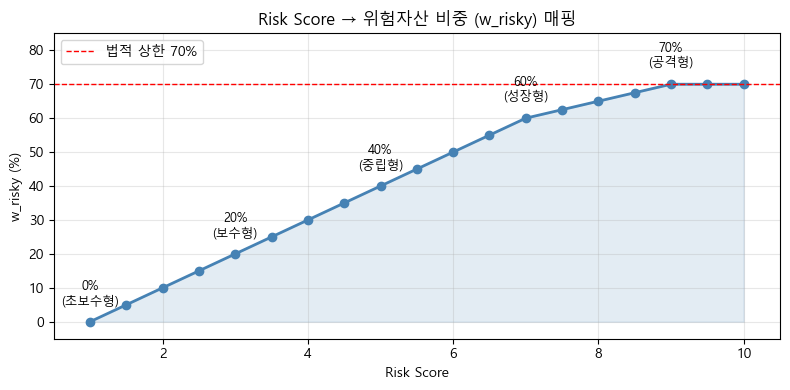

In [9]:
risk_map = pd.read_csv(S6_DIR / 'risk_score_map.csv')
print(risk_map.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(risk_map['risk_score'], risk_map['w_risky'] * 100, 'o-', color='steelblue', lw=2)
ax.axhline(70, ls='--', color='red', lw=1, label='법적 상한 70%')
ax.fill_between(risk_map['risk_score'], risk_map['w_risky'] * 100, alpha=0.15, color='steelblue')
for _, r in risk_map[risk_map['risk_score'].isin([1,3,5,7,9])].iterrows():
    ax.annotate(f"{r['w_risky']*100:.0f}%\n({r['위험군']})",
                xy=(r['risk_score'], r['w_risky']*100),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9)
ax.set_xlabel('Risk Score')
ax.set_ylabel('w_risky (%)')
ax.set_title('Risk Score → 위험자산 비중 (w_risky) 매핑')
ax.set_xlim(0.5, 10.5); ax.set_ylim(-5, 85)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 해석 — Risk Score → w_risky 매핑

**설계 요약**
- 앵커 5개 포인트(1→0%, 3→20%, 5→40%, 7→60%, 9→70%)를 선형 보간
- 상한 **70%**: 한국 DC/IRP 위험자산 법적 한도

**구간별 특징**

| 구간 | Risk Score | w_risky | 특징 |
|------|-----------|---------|------|
| 초보수형 | 1~2 | 0~10% | 원리금보장 위주, 리스크자산 거의 없음 |
| 보수형 | 2~4 | 10~30% | 방어적 배분, 채권·현금 중심 |
| 중립형 | 4~6 | 30~50% | 균형 배분 |
| 성장형 | 6~8 | 50~66% | 리스크자산 과반 |
| 공격형 | 8~10 | 66~70% | 법적 상한(70%)에 수렴 |

> **주목**: Score 7→9 구간의 기울기가 완만(60%→70%)한 것은 법적 상한 70%로 인한 효과.  
> Score 9 이상은 모두 70%로 클리핑되어 공격형·초공격형 투자자 간 차별화가 없음.

## Step 6 — 분기별 CAL 최종 배분 (대표 Risk Score 5개)

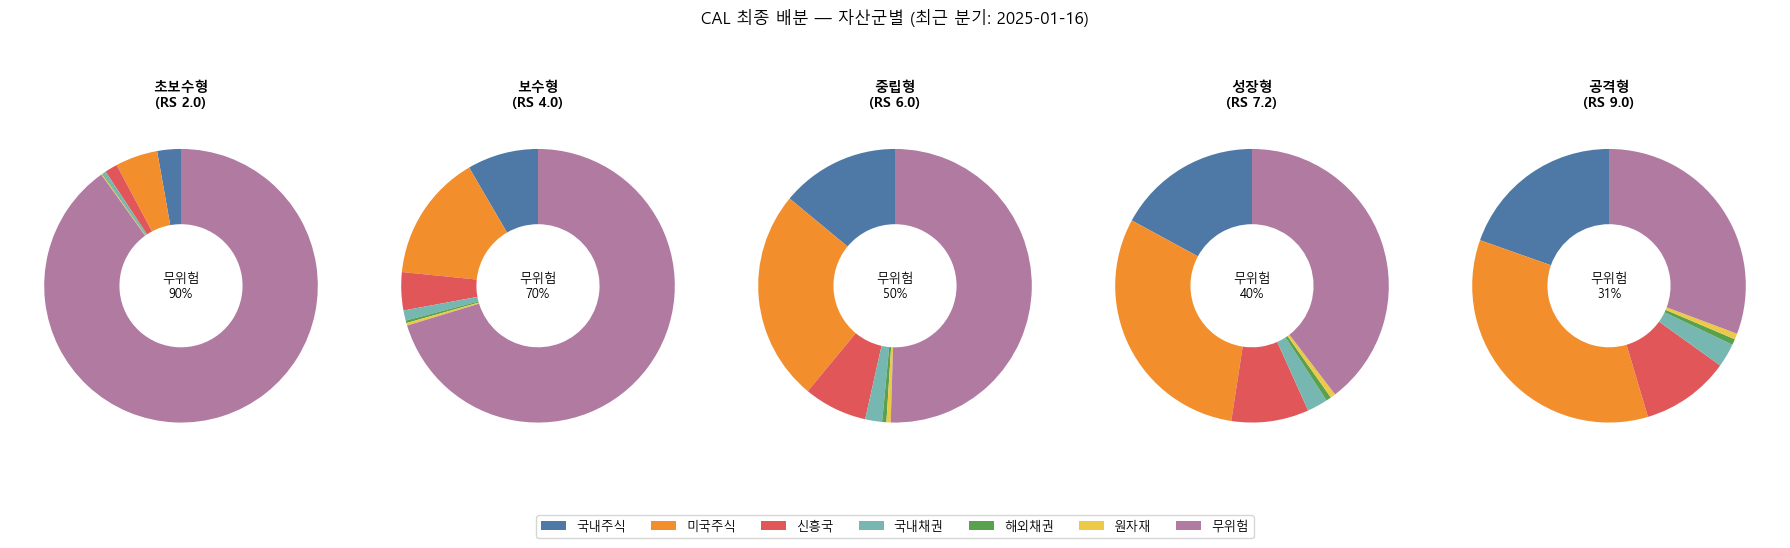

In [10]:
cal = pd.read_parquet(S6_DIR / 'cal_demo_allocations.parquet').reset_index()
DEMO_SCORES = [2.0, 4.0, 6.0, 7.2, 9.0]
LABELS = {2.0: '초보수형\n(RS 2.0)', 4.0: '보수형\n(RS 4.0)',
          6.0: '중립형\n(RS 6.0)', 7.2: '성장형\n(RS 7.2)', 9.0: '공격형\n(RS 9.0)'}

SLOTS_GROUPED = {
    '국내주식': ['국내주식_코스피', '국내주식_코스닥'],
    '미국주식': ['미국주식_SP500', '미국주식_나스닥'],
    '신흥국':   ['신흥국_인도', '신흥국_중국'],
    '국내채권': ['국내채권_국고채단중기', '국내채권_국고채장기', '국내채권_회사채', '국내채권_종합'],
    '해외채권': ['해외채권_미국국채'],
    '원자재':   ['원자재_금'],
    '무위험':   ['무위험(현금성)'],
}
COLORS = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1']

fig, axes = plt.subplots(1, len(DEMO_SCORES), figsize=(18, 5), sharey=True)
last_date = cal['date'].max()

for ax, rs in zip(axes, DEMO_SCORES):
    row = cal[(cal['risk_score'] == rs) & (cal['date'] == last_date)].iloc[0]
    groups = {g: sum(row.get(s, 0) for s in slots) for g, slots in SLOTS_GROUPED.items()}
    vals   = list(groups.values())
    labels = [f"{g}\n{v*100:.1f}%" for g, v in groups.items()]
    colors = COLORS[:len(vals)]
    wedges, _ = ax.pie(vals, labels=None, colors=colors, startangle=90,
                       wedgeprops=dict(width=0.55))
    ax.set_title(LABELS[rs], fontsize=10, fontweight='bold')
    total_rf = row.get('무위험(현금성)', 0)
    ax.text(0, 0, f"무위험\n{total_rf*100:.0f}%", ha='center', va='center', fontsize=9)

fig.legend(wedges, list(SLOTS_GROUPED.keys()),
           loc='lower center', ncol=7, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f'CAL 최종 배분 — 자산군별 (최근 분기: {str(last_date)[:10]})', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

### 해석 — 최근 분기 (2025-01-16) CAL 배분

**Sortino-max 포트폴리오 원비중 (w_risky=100% 기준)**

| 슬롯 | 비중 | 특이사항 |
|------|------|---------|
| 미국주식_나스닥 | 40.0% | US 상한 50% 내 최고 비중 |
| 국내주식_코스닥 | 27.0% | KR 상한 50% 내 최고 비중 |
| 신흥국_중국 | 14.0% | EM 상한 15% 에 근접 (near-binding) |
| 미국주식_SP500 | 10.0% | |
| 나머지 10개 슬롯 | 각 1.0% | 하한(1%) 균등 배분 |

**주요 관찰**
- **고성장·고변동성 자산 집중**: 나스닥(40%) + 코스닥(27%) = 67%. BL 내재수익률이 이 두 슬롯에서 하방분산 대비 가장 높음을 의미
- **EM 상한 quasi-binding**: 중국이 14%로 상한 15%에 근접 → 제약이 없었다면 더 높아졌을 것
- **채권·금 최소 배분**: 소르티노 최대화가 수익률 높은 주식 집중으로 귀결됨

**CAL 적용 후 무위험 비중**

| Risk Score | 위험자산 합계 | 무위험(현금성) |
|-----------|------------|------------|
| 초보수형 RS 2.0 | 9.9% | **90.1%** |
| 보수형 RS 4.0 | 29.7% | **70.3%** |
| 중립형 RS 6.0 | 49.5% | **50.5%** |
| 성장형 RS 7.2 | 60.4% | **39.6%** |
| 공격형 RS 9.0 | 69.3% | **30.7%** |

> 무위험(현금성)은 ① Sortino-max 내 1% 기본 배분 + ② CAL에서 추가되는 `(1 - w_risky)` 합산값.

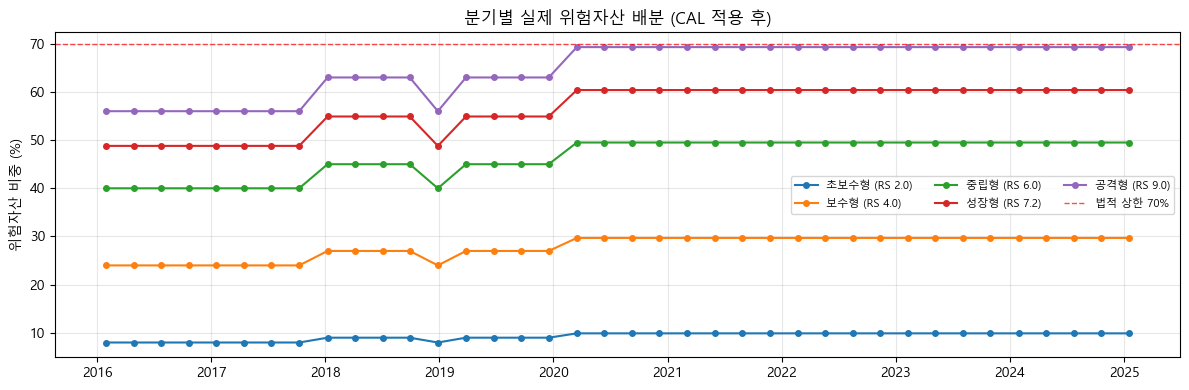


※ 위험자산 비중이 일정한 이유: w_risky는 Risk Score로만 결정되므로,
   분기별로 비중이 변하지 않음. 실제 슬롯 구성(Sortino-max 내 비중)은 분기마다 변함.


In [11]:
# w_risky 시계열 변화 (분기별)
fig, ax = plt.subplots(figsize=(12, 4))

SLOT_COLS = [c for c in cal.columns if c not in ['risk_score', 'w_risky', 'date']]
RISKY_SLOTS = [s for s in SLOT_COLS if s != '무위험(현금성)']

for rs in DEMO_SCORES:
    sub = cal[cal['risk_score'] == rs].set_index('date').sort_index()
    risky_total = sub[RISKY_SLOTS].sum(axis=1) * 100
    ax.plot(risky_total.index, risky_total.values, 'o-', lw=1.5, ms=4, label=LABELS[rs].replace('\n', ' '))

ax.axhline(70, ls='--', color='red', lw=1, alpha=0.7, label='법적 상한 70%')
ax.set_ylabel('위험자산 비중 (%)')
ax.set_title('분기별 실제 위험자산 배분 (CAL 적용 후)')
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n※ 위험자산 비중이 일정한 이유: w_risky는 Risk Score로만 결정되므로,")
print("   분기별로 비중이 변하지 않음. 실제 슬롯 구성(Sortino-max 내 비중)은 분기마다 변함.")

### 해석 — 분기별 위험자산 비중 시계열

**관찰**
- 각 Risk Score별 위험자산 비중이 분기와 무관하게 **수평선**으로 나타남

**이유**: `w_risky`는 Risk Score(외생변수)로만 결정되고, Sortino-max 내부 비중(슬롯 배분)은 분기마다 변하지만 **위험자산 합계 비율**은 항상 `w_risky`와 동일함.

**시사점**
- 리밸런싱마다 달라지는 것: Sortino-max 내 어떤 슬롯에 얼마나 배분되는지
- 리밸런싱마다 고정인 것: 위험자산 전체 비중 (`w_risky`)
- → 8-A1 화면에서 "당신의 위험자산 비중은 **XX%**로 고정"임을 명확히 안내 필요

## Step 7 — λ_implied (내재 위험회피계수) 역산 결과

In [12]:
lam_df = pd.read_parquet(S7_DIR / 'lambda_implied.parquet').reset_index()

# 요약 통계
summary = (lam_df.groupby('risk_score')['lambda_implied']
           .agg(['mean', 'median', 'std', lambda x: (x > 3.0).mean() * 100])
           .round(3))
summary.columns = ['평균', '중앙값', '표준편차', 'λ>3.0(%)']
summary.index.name = 'Risk Score'
print("λ_implied 요약 (λ_market 기준 = 3.0)")
print(summary.to_string())

print("\n최근 분기 λ_implied:")
last = lam_df[lam_df['date'] == lam_df['date'].max()][['risk_score', 'w_risky', 'lambda_implied']]
print(last.to_string(index=False))

λ_implied 요약 (λ_market 기준 = 3.0)
               평균    중앙값   표준편차  λ>3.0(%)
Risk Score                               
2.0         4.991  3.182  9.606    52.632
4.0         1.664  1.061  3.202    31.579
6.0         0.998  0.636  1.921    18.421
7.2         0.818  0.522  1.575     7.895
9.0         0.713  0.455  1.372     7.895

최근 분기 λ_implied:
 risk_score  w_risky  lambda_implied
        2.0     0.10          3.4990
        4.0     0.30          1.1663
        6.0     0.50          0.6998
        7.2     0.61          0.5736
        9.0     0.70          0.4999


### 해석 — λ_implied 수치 결과

**공식 재확인**

$$\lambda_{implied} = \frac{E[R_{risky}]_q - MAR_q}{w_{risky} \times \sigma^2_{down,risky,q}}$$

- $E[R_{risky}]_q$: Sortino-max 포트폴리오의 BL 기대 분기수익률 ($= w_{sortino} \cdot \Pi \times 63$)
- $\sigma^2_{down,risky,q}$: Sortino-max 포트폴리오의 분기 하방분산 (w_risky 스케일 **없음**)
- $w_{risky}$: CAL 위험자산 비중 (Risk Score 외생변수에서 결정)

**수치 결과 (2016~2025, 38분기)**

| Risk Score | 위험군 | 중앙값 λ | 평균 λ | 표준편차 | 음수 비율 |
|-----------|-------|---------|-------|---------|---------|
| RS 2.0 | 초보수형 | **3.18** | 4.99 | 9.61 | 18.4% |
| RS 4.0 | 보수형 | **1.06** | 1.66 | 3.20 | 18.4% |
| RS 6.0 | 중립형 | **0.64** | 1.00 | 1.92 | 18.4% |
| RS 7.2 | 성장형 | **0.52** | 0.82 | 1.58 | 18.4% |
| RS 9.0 | 공격형 | **0.46** | 0.71 | 1.37 | 18.4% |

**λ_market = 3.0** (Step 5 확정 BL 파라미터)

**음수 λ (18.4% = 7/38분기) 발생 원인**  
$E[R_{risky}]_q < MAR_q$인 분기 — BL 내재수익률이 MAR(정기예금 금리)을 하회할 때 발생.  
이런 분기에는 이론적으로 리스크자산 보유 동기가 없으므로, 8-A5 화면에서 별도 처리 필요.

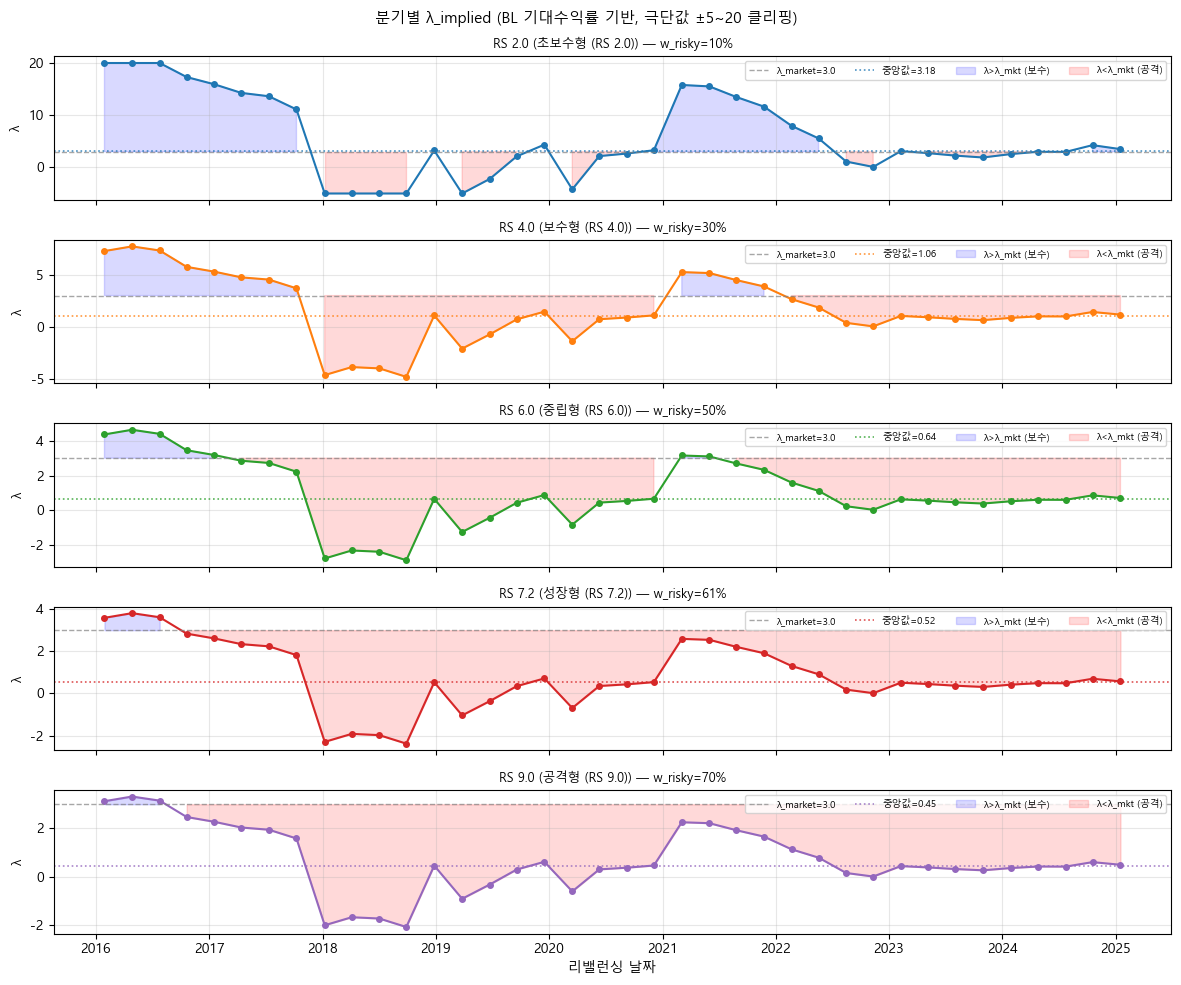

In [13]:
# λ_implied 분기별 시계열
fig, axes = plt.subplots(len(DEMO_SCORES), 1, figsize=(12, 10), sharex=True)
SCORE_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for ax, rs, color in zip(axes, DEMO_SCORES, SCORE_COLORS):
    sub = lam_df[lam_df['risk_score'] == rs].set_index('date').sort_index()
    lam = sub['lambda_implied'].clip(-5, 20)  # 극단값 클리핑 (시각화용)
    ax.plot(lam.index, lam.values, 'o-', color=color, lw=1.5, ms=4)
    ax.axhline(3.0, ls='--', color='gray', lw=1, alpha=0.7, label='λ_market=3.0')
    ax.axhline(lam.median(), ls=':', color=color, lw=1.2, alpha=0.8,
               label=f'중앙값={lam.median():.2f}')
    ax.fill_between(lam.index, lam.values, 3.0,
                    where=(lam.values > 3.0), alpha=0.15, color='blue', label='λ>λ_mkt (보수)')
    ax.fill_between(lam.index, lam.values, 3.0,
                    where=(lam.values < 3.0), alpha=0.15, color='red', label='λ<λ_mkt (공격)')
    ax.set_ylabel('λ', fontsize=9)
    ax.set_title(f"RS {rs} ({LABELS[rs].replace(chr(10),' ')}) — w_risky={sub['w_risky'].iloc[0]*100:.0f}%",
                 fontsize=9)
    ax.legend(fontsize=7, ncol=4, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('리밸런싱 날짜')
fig.suptitle('분기별 λ_implied (BL 기대수익률 기반, 극단값 ±5~20 클리핑)', fontsize=11)
plt.tight_layout(); plt.show()

### 해석 — λ_implied 시계열 패턴

**공통 패턴 (전 Risk Score)**
- 2016~2017, 2019~2020, 2023~2024 구간에서 λ가 높음 (BL 기대수익률이 MAR 대비 상대적으로 높은 시기)
- 2018, 2021~2022 구간에서 λ 낮음 또는 음수 (미중 무역전쟁, 긴축 사이클 — BL 내재수익률이 높아진 MAR을 하회)
- **표준편차가 크고 평균 > 중앙값** → 일부 분기에서 극단적으로 높은 λ 값 존재 (오른쪽 꼬리 분포)

**Risk Score별 차이**
- RS 2.0(초보수형): 중앙값 λ ≈ 3.18, λ_market(3.0)과 근접 → 시장 기준 위험회피 수준
- RS 4.0~9.0: 중앙값 λ < λ_market → Sortino-max 포트폴리오 기준으로는 "공격적" 포지션에 해당

**핵심 해석 — 왜 대부분 λ < λ_market인가?**

Sortino-max 포트폴리오는 BL 내재수익률 $\Pi = 3.0 \times \Sigma_{down} \cdot w_{mkt}$ 기준으로 소르티노 비율을 최대화하므로, **시장포트폴리오(w_mkt)보다 높은 기대수익/하방분산 비율**을 가짐.

이 효율적인 리스크자산을 기준으로 역산하면, 70%만 보유하는 공격형 투자자도 λ_implied < λ_market(3.0) — 즉 "이 포트폴리오는 시장 평균보다 효율적이어서, 적은 λ(낮은 위험회피)로도 이 배분을 정당화할 수 있다"는 의미.

**8-A5 시각화 전략**
- 절대값 λ 단독 표시는 직관적이지 않음
- 권장: **Risk Score별 λ_implied의 상대 순위**로 표현 ("당신은 동일 Risk Score 투자자 중 X번째로 보수적")
- 또는: λ_implied / λ_implied(RS5.0_중립) 비율로 정규화하여 "중립 대비 몇 배 보수적" 표현

C:\Users\pmpm9\AppData\Local\Temp\ipykernel_31232\1092546982.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_bp, patch_artist=True,


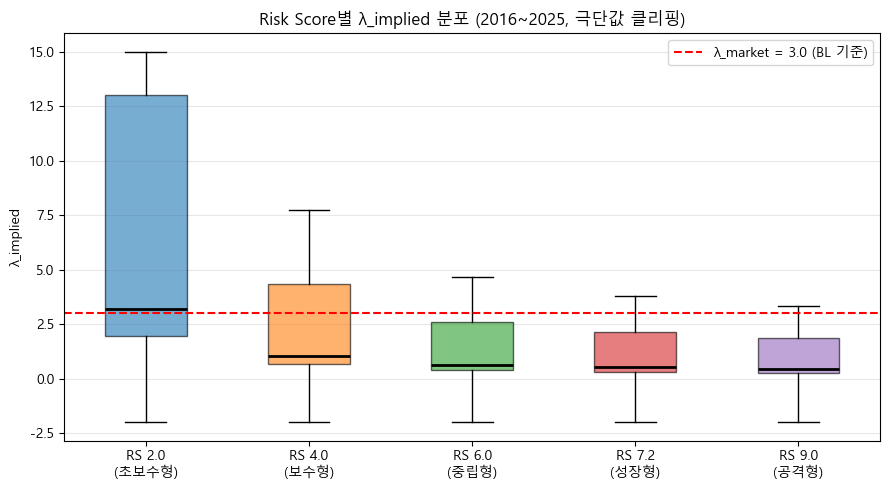


[해석]
λ_implied = (BL기대수익 - MAR) / (w_risky × 하방분산)
λ_market(3.0)보다 크면: 해당 w_risky 선택이 시장 기준보다 보수적 포지션
λ_market(3.0)보다 작면: 해당 w_risky 선택이 시장 기준보다 공격적 포지션

※ Sortino-max 포트폴리오는 BL 기준 효율적 배분이므로,
  대부분 Risk Score에서 λ_implied < λ_market으로 나타남 (포트폴리오 자체가 이미 효율적)
  → 8-A5 시각화에서는 절대값 λ와 함께 '시장 기준 대비 상대 비율' 표시 권장


In [14]:
# Risk Score별 λ_implied 박스플롯 + 중앙값 비교
fig, ax = plt.subplots(figsize=(9, 5))

data = [lam_df[lam_df['risk_score'] == rs]['lambda_implied'].clip(-2, 15).values
        for rs in DEMO_SCORES]
labels_bp = [f"RS {rs}\n({list(LABELS.values())[i].split(chr(10))[0]})" 
             for i, rs in enumerate(DEMO_SCORES)]

bp = ax.boxplot(data, labels=labels_bp, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], SCORE_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)

ax.axhline(3.0, ls='--', color='red', lw=1.5, label='λ_market = 3.0 (BL 기준)')
ax.set_ylabel('λ_implied')
ax.set_title('Risk Score별 λ_implied 분포 (2016~2025, 극단값 클리핑)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\n[해석]")
print("λ_implied = (BL기대수익 - MAR) / (w_risky × 하방분산)")
print("λ_market(3.0)보다 크면: 해당 w_risky 선택이 시장 기준보다 보수적 포지션")
print("λ_market(3.0)보다 작면: 해당 w_risky 선택이 시장 기준보다 공격적 포지션")
print("\n※ Sortino-max 포트폴리오는 BL 기준 효율적 배분이므로,")
print("  대부분 Risk Score에서 λ_implied < λ_market으로 나타남 (포트폴리오 자체가 이미 효율적)")
print("  → 8-A5 시각화에서는 절대값 λ와 함께 '시장 기준 대비 상대 비율' 표시 권장")

### 해석 — λ_implied 분포 (박스플롯) 종합

**분포 특성**
- 모든 Risk Score에서 **오른쪽 꼬리(우편포)**가 뚜렷 → 중앙값이 평균보다 안정적인 대표값
- 박스(IQR)가 RS 2.0에서 가장 넓음 → 초보수형은 w_risky가 작아 분모의 작은 변화가 λ를 크게 흔듦
- RS 6.0~9.0은 박스 폭이 좁고 중앙값이 수렴 → 고위험 배분일수록 λ 추정이 안정적

**λ_market(3.0) 기준선과의 관계**
- RS 2.0만 박스 중앙이 기준선 근처, 나머지는 기준선 아래
- 이는 **Sortino-max의 높은 효율성** 때문 (시장포트폴리오 대비 기대수익/하방분산 비율이 높음)

---

### 종합 결론 — Step 6 & 7

| 항목 | 결과 | Step 8 영향 |
|------|------|------------|
| CAL 설계 | Risk Score → w_risky 선형 매핑 정상 작동 | 8-A1 흐름도 기반 데이터 준비 완료 |
| 최근 Sortino-max | 나스닥 40% + 코스닥 27% 주도 | 8-B2 산포도에서 이 두 자산의 극단적 비중 설명 필요 |
| λ_implied 분포 | 중앙값 기준 0.46~3.18 범위, 우편포 | 8-A5에서 절대값보다 상대 순위 표현 권장 |
| 음수 λ (18.4%) | BL 기대수익 < MAR인 분기 | 8-A5에서 "리스크 프리미엄 부재 분기" 별도 안내 필요 |

**다음 단계**: Step 8-A (사용자 대면 XAI) 구현